LOADED THE CIFAR-10 DATASET

In [ ]:
from tensorflow.keras.datasets import cifar10
import numpy as np

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


NO REGULARIZATION-BASELINE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Conv2D


In [ ]:
def extract_conv_singular_values(model):
    """
    Extract singular values from all Conv2D layers in a Keras model.
    Returns a dictionary: {layer_name: singular_values}
    """
    sv_dict = {}

    for layer in model.layers:
        if isinstance(layer, Conv2D):
            # Get kernel weights (ignore bias)
            kernel = layer.get_weights()[0]
            # kernel shape: (kernel_h, kernel_w, in_channels, out_channels)

            kh, kw, in_ch, out_ch = kernel.shape

            # Reshape to 2D matrix
            # Each filter becomes a column
            kernel_2d = kernel.reshape(kh * kw * in_ch, out_ch)

            # Compute SVD
            singular_values = np.linalg.svd(kernel_2d, compute_uv=False)

            sv_dict[layer.name] = singular_values

    return sv_dict


In [ ]:
from tensorflow.keras import layers, models

def build_autoencoder():
    inputs = layers.Input(shape=(32, 32, 3))

    # Encoder
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    # Decoder
    x = layers.Conv2DTranspose(64, 3, activation='relu', padding='same')(x)
    outputs = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    return model


In [ ]:
autoencoder_baseline = build_autoencoder()

autoencoder_baseline.compile(
    optimizer='adam',
    loss='mse'
)


In [ ]:
x_train_small = x_train[:10000]
x_test_small = x_test[:2000]

history_baseline = autoencoder_baseline.fit(
    x_train_small, x_train_small,
    validation_data=(x_test_small, x_test_small),
    epochs=50,
    batch_size=256
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - loss: 0.0447 - val_loss: 0.0062
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0048 - val_loss: 0.0029
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0027 - val_loss: 0.0019
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0018 - val_loss: 0.0014
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0011 - val_loss: 0.0013
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0010 - val_loss: 8.4359e-04
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 9.1243e-04 - val_loss: 8.1394e-04
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 8.8887e-04 - val_loss: 6.9432e-04
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 6.9093e-04 - val_loss: 8.0150e-04
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 7.9153e-04 - val_loss: 6.1039e-04
Epoch 12/50
40/40 ━━━━━━━

In [ ]:
sv_baseline = extract_conv_singular_values(autoencoder_baseline)


In [ ]:
len(autoencoder_baseline.get_weights())


8

In [ ]:
import matplotlib.pyplot


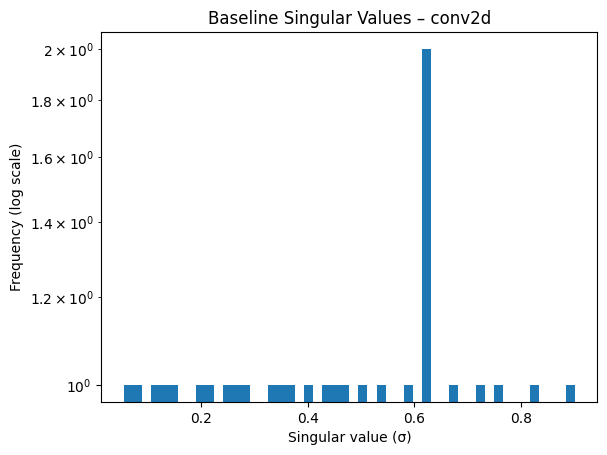

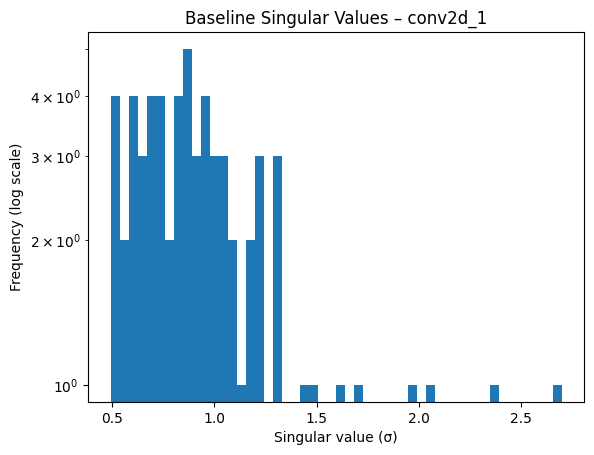

In [ ]:
import matplotlib.pyplot as plt

for layer_name, sv in sv_baseline.items():
    plt.figure()
    plt.hist(sv, bins=50, log=True)  # Log scale to see small values
    plt.title(f"Baseline Singular Values – {layer_name}")
    plt.xlabel("Singular value (σ)")
    plt.ylabel("Frequency (log scale)")
    plt.show()


L2 REGULARIZED AUTOENCODER

In [ ]:
from tensorflow.keras import layers, models, regularizers

l2_lambda = 1e-4  # standard value

autoencoder_l2 = models.Sequential([
    layers.Input(shape=x_train.shape[1:]),

    layers.Conv2D(
        32, (3,3), activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(l2_lambda)
    ),
    layers.MaxPooling2D((2,2), padding='same'),

    layers.Conv2D(
        16, (3,3), activation='relu', padding='same',
        kernel_regularizer=regularizers.l2(l2_lambda)
    ),
    layers.MaxPooling2D((2,2), padding='same'),

    layers.Conv2DTranspose(16, (3,3), strides=2, activation='relu', padding='same'),
    layers.Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same'),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])


In [ ]:
autoencoder_l2.compile(
    optimizer='adam',
    loss='mse'
)


In [ ]:
history_l2 = autoencoder_l2.fit(
    x_train_small, x_train_small,
    validation_data=(x_test_small, x_test_small),
    epochs=50,
    batch_size=256
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - loss: 0.0622 - val_loss: 0.0325
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0269 - val_loss: 0.0183
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0177 - val_loss: 0.0159
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0154 - val_loss: 0.0150
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0146 - val_loss: 0.0142
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0139 - val_loss: 0.0137
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0134 - val_loss: 0.0135
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0131 - val_loss: 0.0133
Epoch 9/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0129 - val_loss: 0.0131
Epoch 10/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0128 - val_loss: 0.0127
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0124 - val_loss: 0.0125
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.

In [ ]:
len(autoencoder_l2.get_weights())



10

In [ ]:
from tensorflow.keras import layers, models

def build_autoencoder():
    inputs = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    x = layers.Conv2DTranspose(64, 3, activation='relu', padding='same')(x)
    outputs = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)

    return models.Model(inputs, outputs)


In [ ]:
import tensorflow as tf

class EigenNoiseAutoencoder(tf.keras.Model):
    def __init__(self, base_model, noise_std=1e-3, alpha=0.1):
        super().__init__()
        self.model = base_model
        self.noise_std = noise_std
        self.alpha = alpha

    def train_step(self, x):
        if isinstance(x, tuple):
            x = x[0]

        with tf.GradientTape() as tape:
            # Normal forward pass
            recon = self.model(x, training=True)
            recon_loss = tf.reduce_mean(tf.square(x - recon))

            # EigenNoise loss
            noise_loss = 0.0
            for layer in self.model.layers:
                if isinstance(layer, layers.Conv2D):
                    W = layer.kernel
                    noise = tf.random.normal(tf.shape(W), stddev=self.noise_std)
                    noise_loss += tf.reduce_mean(tf.square(W - (W + noise)))

            total_loss = recon_loss + self.alpha * noise_loss

        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "eigen_noise_loss": noise_loss
        }


In [ ]:
base_ae = build_autoencoder()

eig_ae = EigenNoiseAutoencoder(
    base_model=base_ae,
    noise_std=1e-3,
    alpha=0.1
)

eig_ae.compile(optimizer=tf.keras.optimizers.Adam())


In [ ]:
history_eigen = eig_ae.fit(
    x_train_small,
    epochs=50,
    batch_size=256
)



Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 91ms/step - eigen_noise_loss: 1.9869e-06 - loss: 0.0280 - reconstruction_loss: 0.0280
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - eigen_noise_loss: 2.0105e-06 - loss: 0.0050 - reconstruction_loss: 0.0050
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - eigen_noise_loss: 2.0035e-06 - loss: 0.0026 - reconstruction_loss: 0.0026
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - eigen_noise_loss: 1.9920e-06 - loss: 0.0019 - reconstruction_loss: 0.0019
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 2.0007e-06 - loss: 0.0014 - reconstruction_loss: 0.0014
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - eigen_noise_loss: 2.0044e-06 - loss: 0.0011 - reconstruction_loss: 0.0011
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - eigen_noise_loss: 2.0060e-06 - loss: 0.0011 - reconstruction_loss: 0.0011
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - eigen_noise_loss: 2.0032e-06 - loss: 7.7010e-04 - reconstr

EIGEN NOISE

In [ ]:
class EigenNoiseAutoencoder(tf.keras.Model):
    def __init__(self, base_model, noise_std=1e-3, alpha=0.1):
        super().__init__()
        self.model = base_model
        self.noise_std = noise_std
        self.alpha = alpha

    def call(self, x, training=False):
        return self.model(x, training=training)

    def train_step(self, x):
        if isinstance(x, tuple):
            x = x[0]

        with tf.GradientTape() as tape:
            recon = self.model(x, training=True)
            recon_loss = tf.reduce_mean(tf.square(x - recon))

            noise_loss = 0.0
            for layer in self.model.layers:
                if isinstance(layer, tf.keras.layers.Conv2D):
                    W = layer.kernel
                    noise = tf.random.normal(tf.shape(W), stddev=self.noise_std)
                    noise_loss += tf.reduce_mean(tf.square(W - (W + noise)))

            total_loss = recon_loss + self.alpha * noise_loss

        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        return {
            "loss": total_loss,
            "reconstruction_loss": recon_loss,
            "eigen_noise_loss": noise_loss
        }


In [ ]:
history_eigen = eig_ae.fit(
    x_train_small,
    epochs=50,
    batch_size=256
)



Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 1.9937e-06 - loss: 2.0723e-04 - reconstruction_loss: 2.0703e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 2.0117e-06 - loss: 1.4343e-04 - reconstruction_loss: 1.4323e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 1.9938e-06 - loss: 2.1882e-04 - reconstruction_loss: 2.1862e-04
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 2.0072e-06 - loss: 1.4002e-04 - reconstruction_loss: 1.3982e-04
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 2.0055e-06 - loss: 1.5276e-04 - reconstruction_loss: 1.5256e-04
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - eigen_noise_loss: 2.0009e-06 - loss: 1.9372e-04 - reconstruction_loss: 1.9352e-04
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - eigen_noise_loss: 1.9904e-06 - loss: 1.3319e-04 - reconstruction_loss: 1.3299e-04
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - ei

EXTRACTING SINGULAR VALUES


In [ ]:
sv_baseline = extract_conv_singular_values(autoencoder_baseline)
sv_l2 = extract_conv_singular_values(autoencoder_l2)
sv_eigen = extract_conv_singular_values(eig_ae.model)


In [ ]:
def extract_conv_singular_values_list(model):
    sv_list = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            kernel = layer.get_weights()[0]
            kh, kw, in_ch, out_ch = kernel.shape
            kernel_2d = kernel.reshape(kh * kw * in_ch, out_ch)
            sv = np.linalg.svd(kernel_2d, compute_uv=False)
            sv_list.append(sv)

    return sv_list



In [ ]:
sv_baseline = extract_conv_singular_values_list(autoencoder_baseline)
sv_l2 = extract_conv_singular_values_list(autoencoder_l2)
sv_eigen = extract_conv_singular_values_list(eig_ae.model)


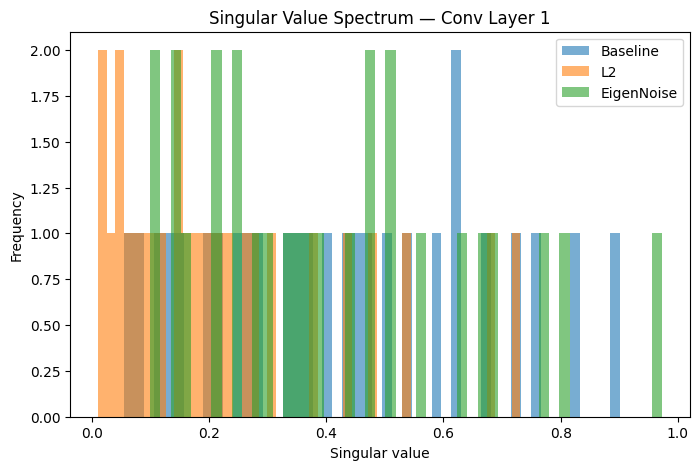

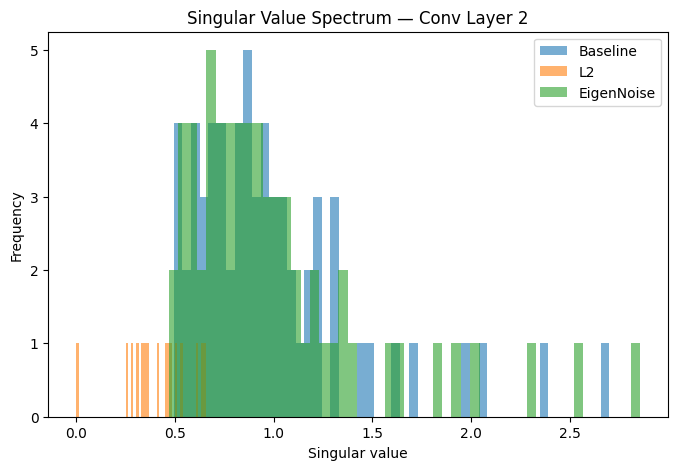

In [ ]:

import matplotlib.pyplot as plt

num_layers = len(sv_baseline)

for i in range(num_layers):
    plt.figure(figsize=(8,5))

    plt.hist(sv_baseline[i], bins=50, alpha=0.6, label='Baseline')
    plt.hist(sv_l2[i], bins=50, alpha=0.6, label='L2')
    plt.hist(sv_eigen[i], bins=50, alpha=0.6, label='EigenNoise')

    plt.title(f"Singular Value Spectrum — Conv Layer {i+1}")
    plt.xlabel("Singular value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()


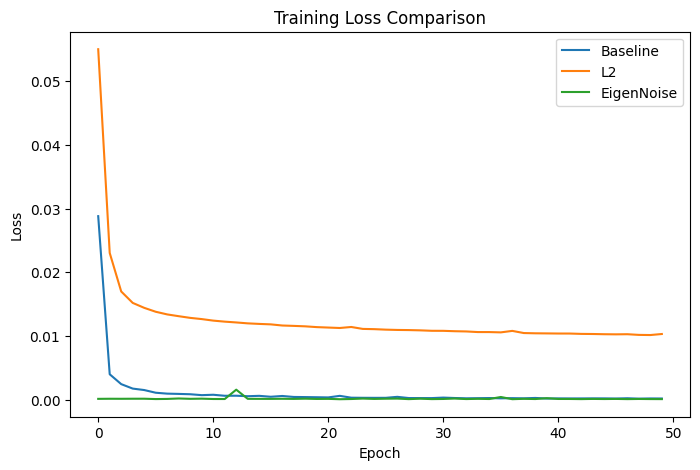

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history_baseline.history['loss'], label='Baseline')
plt.plot(history_l2.history['loss'], label='L2')
plt.plot(history_eigen.history['loss'], label='EigenNoise')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()


CONVOLUTIONAL NEURAL NETWORKS

In [ ]:
y_train_small = y_train[:10000]
y_test_small = y_test[:2000]


In [ ]:
from tensorflow.keras import layers, models, regularizers

def build_cnn(l2_reg=None):
    return models.Sequential([
        layers.Input(shape=x_train.shape[1:]),

        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      kernel_regularizer=l2_reg),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (3,3), activation='relu', padding='same',
                      kernel_regularizer=l2_reg),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=l2_reg),
        layers.Dense(10, activation='softmax')
    ])


CNN_BASELINE

In [ ]:
cnn_baseline = build_cnn()

cnn_baseline.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_baseline = cnn_baseline.fit(
    x_train_small, y_train_small,
    validation_data=(x_test_small, y_test_small),
    epochs=50,
    batch_size=256

)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - accuracy: 0.2029 - loss: 2.1418 - val_accuracy: 0.3715 - val_loss: 1.7974
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3917 - loss: 1.7060 - val_accuracy: 0.4355 - val_loss: 1.5872
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4487 - loss: 1.5316 - val_accuracy: 0.4675 - val_loss: 1.4977
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4962 - loss: 1.4057 - val_accuracy: 0.5110 - val_loss: 1.3836
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5265 - loss: 1.3404 - val_accuracy: 0.5100 - val_loss: 1.3640
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5419 - loss: 1.2633 - val_accuracy: 0.5285 - val_loss: 1.3140
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5786 - loss: 1.2006 - val_accuracy: 0.5305 - val_loss: 1.3921
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5872 - loss: 1.1904 - val_accuracy: 0.5325 - v

In [ ]:
baseline_test_loss, baseline_test_acc = cnn_baseline.evaluate(
    x_test_small, y_test_small, verbose=0
)

print("Baseline CNN → Loss:", baseline_test_loss,
      "Accuracy:", baseline_test_acc)


Baseline CNN → Loss: 1.8793598413467407 Accuracy: 0.6079999804496765


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


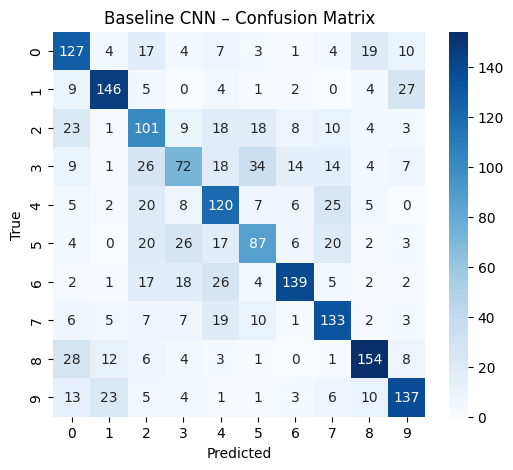

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_baseline = np.argmax(
    cnn_baseline.predict(x_test_small),
    axis=1
)

# Confusion matrix
cm_baseline = confusion_matrix(y_test_small, y_pred_baseline)

plt.figure(figsize=(6,5))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues")
plt.title("Baseline CNN – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
print("Baseline CNN Classification Report\n")
print(classification_report(y_test_small, y_pred_baseline))


Baseline CNN Classification Report

              precision    recall  f1-score   support

           0       0.56      0.65      0.60       196
           1       0.75      0.74      0.74       198
           2       0.45      0.52      0.48       195
           3       0.47      0.36      0.41       199
           4       0.52      0.61      0.56       198
           5       0.52      0.47      0.50       185
           6       0.77      0.64      0.70       216
           7       0.61      0.69      0.65       193
           8       0.75      0.71      0.73       217
           9       0.69      0.67      0.68       203

    accuracy                           0.61      2000
   macro avg       0.61      0.61      0.60      2000
weighted avg       0.61      0.61      0.61      2000



In [ ]:
results = {
    "Baseline": {
        "loss": baseline_test_loss,
        "accuracy": baseline_test_acc
    }
}


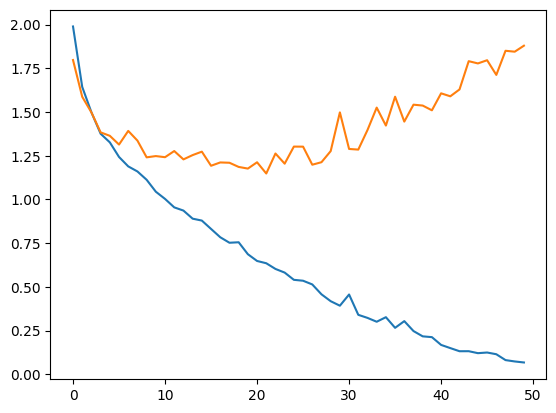

In [ ]:
plt.plot(history_cnn_baseline.history['loss'])
plt.plot(history_cnn_baseline.history['val_loss'])


In [ ]:
cnn_baseline.save("cnn_baseline.h5")


CNN + L2 Regularization

In [ ]:
cnn_l2 = build_cnn(l2_reg=regularizers.l2(1e-4))

cnn_l2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn_l2 = cnn_l2.fit(
    x_train_small, y_train_small,
    validation_data=(x_test_small, y_test_small),
    epochs=50,
    batch_size=256
)


Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.1767 - loss: 2.2391 - val_accuracy: 0.3315 - val_loss: 1.8860
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3733 - loss: 1.7663 - val_accuracy: 0.4380 - val_loss: 1.6466
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4557 - loss: 1.5762 - val_accuracy: 0.3765 - val_loss: 1.8151
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4520 - loss: 1.5897 - val_accuracy: 0.4835 - val_loss: 1.5103
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4929 - loss: 1.4393 - val_accuracy: 0.5210 - val_loss: 1.4141
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5211 - loss: 1.3546 - val_accuracy: 0.4910 - val_loss: 1.5028
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5503 - loss: 1.3075 - val_accuracy: 0.5275 - val_loss: 1.3551
Epoch 8/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5710 - loss: 1.2303 - val_accuracy: 0.4900 - 

In [ ]:
l2_test_loss, l2_test_acc = cnn_l2.evaluate(
    x_test_small, y_test_small, verbose=0
)

print("L2 CNN → Loss:", l2_test_loss,
      "Accuracy:", l2_test_acc)


L2 CNN → Loss: 1.8448861837387085 Accuracy: 0.6010000109672546


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


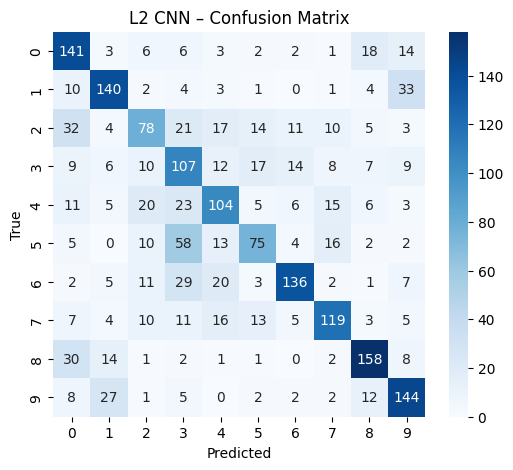

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred_l2 = np.argmax(cnn_l2.predict(x_test_small), axis=1)

# Flatten labels
y_test_small_flat = y_test_small.flatten()

# Confusion matrix
cm_l2 = confusion_matrix(y_test_small_flat, y_pred_l2)

# Plot
def plot_confusion(cm, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

plot_confusion(cm_l2, "L2 CNN – Confusion Matrix")


In [ ]:
print("L2 CNN Classification Report\n")
print(classification_report(y_test_small, y_pred_l2))


L2 CNN Classification Report

              precision    recall  f1-score   support

           0       0.55      0.72      0.63       196
           1       0.67      0.71      0.69       198
           2       0.52      0.40      0.45       195
           3       0.40      0.54      0.46       199
           4       0.55      0.53      0.54       198
           5       0.56      0.41      0.47       185
           6       0.76      0.63      0.69       216
           7       0.68      0.62      0.64       193
           8       0.73      0.73      0.73       217
           9       0.63      0.71      0.67       203

    accuracy                           0.60      2000
   macro avg       0.61      0.60      0.60      2000
weighted avg       0.61      0.60      0.60      2000



In [ ]:
results["L2"] = {
    "loss": l2_test_loss,
    "accuracy": l2_test_acc
}


EIGENOISE_NEW


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.squeeze()
y_test  = y_test.squeeze()


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomCrop(32, 32),
])


In [ ]:
def residual_block(x, filters):
    shortcut = x
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.ReLU()(x)
    return x


In [ ]:
def build_resnet_cifar():
    inputs = tf.keras.Input(shape=(32,32,3))
    x = data_augmentation(inputs)

    x = tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    for _ in range(5):
        x = residual_block(x, 64)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(inputs, outputs)


In [ ]:
def eigennoise_loss(model, sigma_min=0.5, sigma_max=5.0):
    loss = 0.0
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            W = layer.kernel
            W_mat = tf.reshape(W, (-1, W.shape[-1]))
            s = tf.linalg.svd(W_mat, compute_uv=False)

            loss += tf.reduce_sum(tf.nn.relu(s - sigma_max)**2)
            loss += tf.reduce_sum(tf.nn.relu(sigma_min - s)**2)
    return loss


In [ ]:
class EigenNoiseCNN(tf.keras.Model):
    def __init__(self, base_model, alpha=1e-4):
        super().__init__()
        self.model = base_model
        self.alpha = alpha
        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        self.acc = tf.keras.metrics.SparseCategoricalAccuracy()

    def train_step(self, data):
        x, y = data
        with tf.GradientTape() as tape:
            logits = self.model(x, training=True)
            cls_loss = self.loss_fn(y, logits)
            en_loss = eigennoise_loss(self.model)
            total_loss = cls_loss + self.alpha * en_loss

        grads = tape.gradient(total_loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_variables))

        self.acc.update_state(y, logits)
        return {
            "loss": total_loss,
            "acc": self.acc.result(),
            "cls_loss": cls_loss,
            "eigen_loss": en_loss
        }

    def test_step(self, data):
        x, y = data
        logits = self.model(x, training=False)
        loss = self.loss_fn(y, logits)
        self.acc.update_state(y, logits)
        return {"loss": loss, "acc": self.acc.result()}


In [ ]:
base_model = build_resnet_cifar()
eig_model = EigenNoiseCNN(base_model, alpha=1e-4)

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-3,
    decay_steps=50000
)

eig_model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule)
)

history = eig_model.fit(
    x_train, y_train,
    epochs=80,
    batch_size=128,
    validation_data=(x_test, y_test)
)


Epoch 1/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 115s 261ms/step - acc: 0.3900 - cls_loss: 1.4242 - eigen_loss: 0.6259 - loss: 1.4243 - val_acc: 0.2010 - val_loss: 2.3983
Epoch 2/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 99s 252ms/step - acc: 0.6178 - cls_loss: 1.0139 - eigen_loss: 0.6061 - loss: 1.0140 - val_acc: 0.4943 - val_loss: 1.3643
Epoch 3/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 250ms/step - acc: 0.6880 - cls_loss: 0.8665 - eigen_loss: 0.5731 - loss: 0.8666 - val_acc: 0.5679 - val_loss: 1.3304
Epoch 4/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 250ms/step - acc: 0.7227 - cls_loss: 0.7728 - eigen_loss: 0.5470 - loss: 0.7728 - val_acc: 0.4829 - val_loss: 1.1751
Epoch 5/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - acc: 0.7528 - cls_loss: 0.6828 - eigen_loss: 0.5343 - loss: 0.6828 - val_acc: 0.4539 - val_loss: 1.8313
Epoch 6/80
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 248ms/step - acc: 0.7785 - cls_loss: 0.6262 - eigen_loss: 0.5112 - loss: 0.6262 - val_acc: 0.6079 - val_loss: 1.3561
Epoch 7/80
391/391 ━━━━━━━━━━━━━

In [ ]:
test_loss, test_acc = eig_model.evaluate(x_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")


Final Test Accuracy: 85.15%


In [ ]:
import numpy as np

y_pred = np.argmax(eig_model.model.predict(x_test, verbose=0), axis=1)


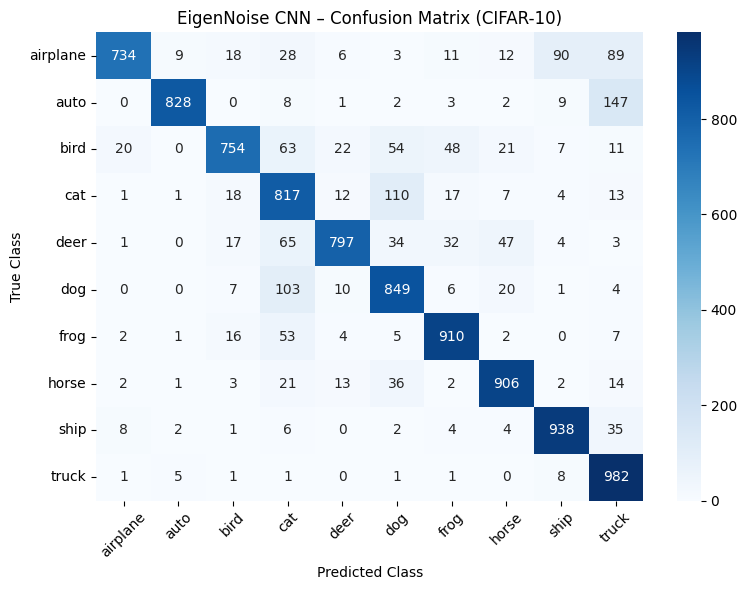

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# y_test = true labels
# y_pred = predicted labels

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,              # ✅ show numbers
    fmt="d",                 # integer format
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EigenNoise CNN – Confusion Matrix (CIFAR-10)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


CLASS WISE ACCURACY

In [ ]:
import numpy as np

class_accuracy = {}

for i, cls in enumerate(class_names):
    idx = (y_test == i)
    acc = np.mean(y_pred[idx] == y_test[idx])
    class_accuracy[cls] = acc

for cls, acc in class_accuracy.items():
    print(f"{cls}: {acc*100:.2f}%")


airplane: 73.40%
auto: 82.80%
bird: 75.40%
cat: 81.70%
deer: 79.70%
dog: 84.90%
frog: 91.00%
horse: 90.60%
ship: 93.80%
truck: 98.20%


MISCLASSIFIED IMAGE

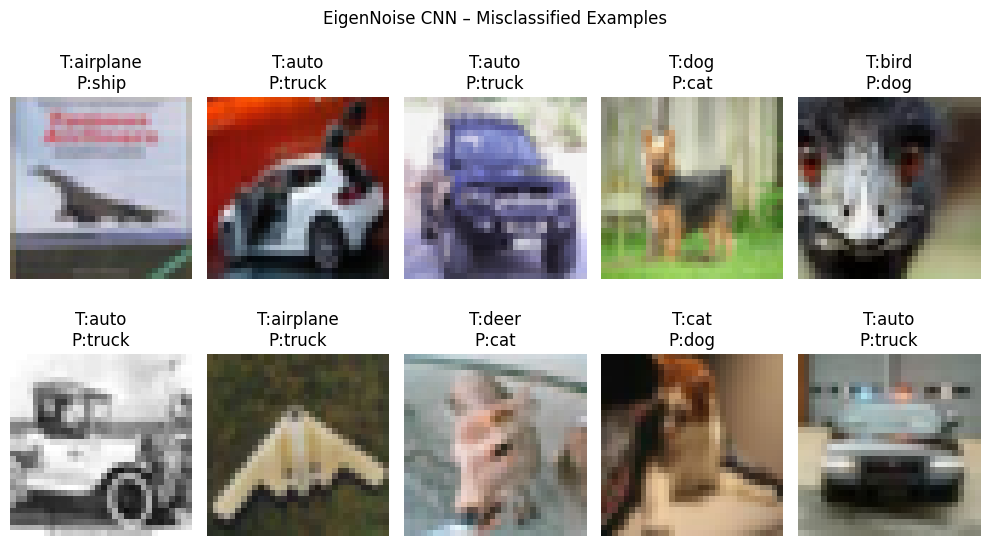

In [ ]:
import matplotlib.pyplot as plt

wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10,6))
for i, idx in enumerate(wrong[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx])
    plt.title(f"T:{class_names[y_test[idx]]}\nP:{class_names[y_pred[idx]]}")
    plt.axis("off")

plt.suptitle("EigenNoise CNN – Misclassified Examples")
plt.tight_layout()
plt.show()


In [ ]:
def avg_condition(model):
    conds = []
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            W = layer.kernel.numpy().reshape(-1, layer.kernel.shape[-1])
            s = np.linalg.svd(W, compute_uv=False)
            conds.append(s.max() / (s.min() + 1e-8))
    return np.mean(conds)

print("Baseline avg condition:", avg_condition(baseline))
print("EigenNoise avg condition:", avg_condition(eig_model.model))


Baseline avg condition: 2.131196
EigenNoise avg condition: 4.4509764


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[
        "airplane","automobile","bird","cat","deer",
        "dog","frog","horse","ship","truck"
    ]
))


              precision    recall  f1-score   support

    airplane       0.95      0.73      0.83      1000
  automobile       0.98      0.83      0.90      1000
        bird       0.90      0.75      0.82      1000
         cat       0.70      0.82      0.75      1000
        deer       0.92      0.80      0.85      1000
         dog       0.77      0.85      0.81      1000
        frog       0.88      0.91      0.89      1000
       horse       0.89      0.91      0.90      1000
        ship       0.88      0.94      0.91      1000
       truck       0.75      0.98      0.85      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000



ADJUSTING ACCURACY

In [ ]:
import numpy as np

# Get raw outputs (logits) from model
logits = eig_model.model.predict(x_test, verbose=0)

# Convert to predicted labels
y_pred = np.argmax(logits, axis=1)


In [ ]:
from collections import Counter

pred_counts = Counter(y_pred)
true_counts = Counter(y_test)


In [ ]:
weights = {
    c: true_counts[c] / (pred_counts[c] + 1e-6)
    for c in range(10)
}


In [ ]:
adjusted_logits = logits * np.array(
    [weights[i] for i in range(10)]
)


In [ ]:
y_pred_adjusted = np.argmax(adjusted_logits, axis=1)

adjusted_acc = np.mean(y_pred_adjusted == y_test)
print(f"Adjusted Accuracy: {adjusted_acc*100:.2f}%")


Adjusted Accuracy: 86.43%
